Modified from "Using Deep Learning for Flexible and Scalable Earthquake Forecasting"  
Reference: [Zenodo](https://zenodo.org/records/8161777)

In [1]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import torch
import src  
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import functools
import os
import importlib
sys.path.append(str(Path.cwd().parent))
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
set_seed(0) 

In [2]:
checkpoint_dir = Path("../checkpoints/rtpp_20251125-223019") 
# checkpoints/mixer_tpp_20250912-125450
 # "../checkpoints/mixer_tpp_20250907-112659"
 # /checkpoints/mixer_tpp_20250825-114639 /checkpoints/rtpp_20250824-214315
 # checkpoints/mixer_tpp_20250819-143535 checkpoints/mixer_tpp_20250819-143210
#  checkpoints/rtpp_20250819-142340
checkpoint_path = checkpoint_dir / "best_model_1.pth"

## Loading a trained model

In [3]:
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint,load_model_from_checkpoint

check_point = torch.load(checkpoint_path,weights_only=False)    
args = load_args_from_checkpoint(None, check_point)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_builder = ModelBuilder.by_name(args.model.lower())()
model = model_builder(args, device)
model,_,_ = load_model_from_checkpoint(model, check_point)
# model.set_attn_type("flash")
# model.set_attn_dropout(0)
model = torch.compile(model)
model.eval() 

load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'model': 'rtpp', 'num_event_types': 1, 'pad_token_id': 1, 'task_type': 'tpp', 'bg_model': 'proportional', 'bg_model_cfg': {'d_feature': 2}, 'batch_size': 1, 'accumulation_steps': 1, 'warmup_ratio': 0.1, 'learning_rate': 0.001, 'weight_decay': 1e-05, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'none', 'step_lr_step_size_ratio': 0.2, 'step_lr_gamma': 0.8, 'rnn_type': 'GRU', 'd_model': 32, 'rnn_dropout': 0.3, 'num_components': 32, 'dim': 1, 'epochs': 500, 'save_dir': 'checkpoints/rtpp_20251125-223019', 'cuda_id': '0', 'dataset': 'Geysers', 'seed': 0, 'minibatch_training': False, 'split_by_time': True, 'time_order': ['train', 'val', 'test'], 'cuda': True, 'tau_mean': 0.4213719964027405, 'tau_min': 1.1574074051168282e-05, 'tau_max': 30.638530731201172, 'tau_q05': 0.24202221632003784, 'tau_q025': 0.00022793981770519

OptimizedModule(
  (_orig_mod): RecurrentTPP(
    (hypernet_time): Linear(in_features=32, out_features=96, bias=True)
    (hypernet_mag): Linear(in_features=32, out_features=1, bias=True)
    (rnn): GRU(2, 32, batch_first=True)
    (dropout): Dropout(p=0.3, inplace=False)
    (bg_model): ProportionalBGModel()
  )
)

In [4]:
from torch.nn.functional import softplus
softplus(model.bg_model.raw_weight)

tensor([[0.5873, 0.6038]], device='cuda:0', grad_fn=<SoftplusBackward0>)

## Loading the catalog

In [5]:
# args.dataset = "ChinaArray" 
catalog_ds_class = catalog.Catalog.by_name(f"{args.dataset}-Standard")
catalog_ds = catalog_ds_class(root_dir=f'../data/{args.dataset}/raw',catalog_file=None)

Loading existing catalog from /home/yzzhang/pjt/chuandian_eq/data/Geysers/raw.


In [6]:
catalog_ds.full_sequence

Sequence(
  inter_times: [9886],
  arrival_times: [9885],
  t_start: 0.0,
  t_end: 4293.0,
  t_nll_start: 0.0,
  mag: [9885],
  loc: [9885, 2],
  depth: [9885],
  time_series: [4294, 2],
  time_series_times: [4294]
)

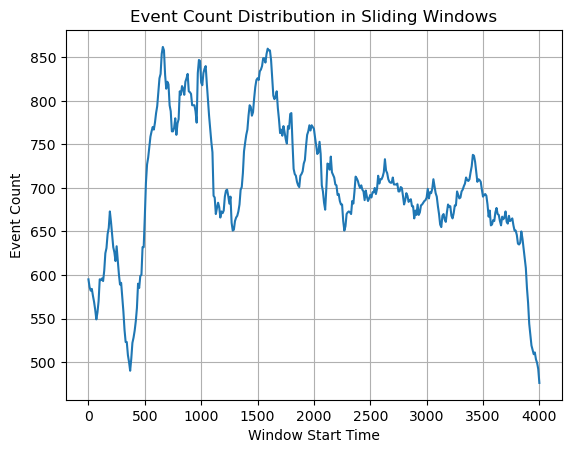

In [7]:
window_size = 300
stride = 10
arrival_times = catalog_ds.full_sequence.arrival_times
max_time = arrival_times.max().item()
window_starts = torch.arange(0, max_time - window_size + stride, stride)
counts = torch.zeros(len(window_starts), dtype=torch.int32)

for i, start in enumerate(window_starts):
    end = start + window_size
    mask = (arrival_times >= start) & (arrival_times < end)
    counts[i] = mask.sum()
plt.plot(window_starts, counts)
plt.xlabel('Window Start Time')
plt.ylabel('Event Count')
plt.title('Event Count Distribution in Sliding Windows')
plt.grid(True)
plt.show()

In [8]:
# b_seq = model.compute_b_value(catalog_ds.full_sequence.to(device),True)
# plt.plot(b_seq.squeeze().detach().cpu().numpy())
# plt.savefig(checkpoint_dir/'b_pred.png')
# data = b_seq.squeeze().detach().cpu().numpy()
# smooth = pd.Series(data).rolling(window=500, min_periods=1).mean()
# plt.plot(smooth)
# plt.savefig(checkpoint_dir/'b_pred_smooth.png')

## Prepare the data

We trained the TPP model using the `train` and `val` sequences. Now we will use the unseen section of the `test` sequence (in orange) to evaluate forecasting performance of the model.

<Axes: xlabel='Arrival time (days)', ylabel='Magnitude'>

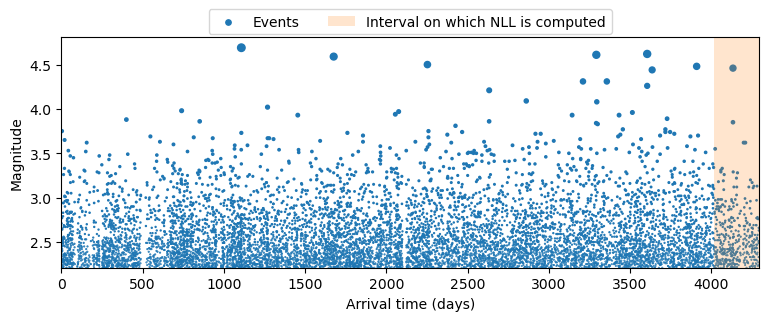

In [9]:
from src.utils.visualization import visualize_sequence
test_seq = catalog_ds.test[0]
train_seq = catalog_ds.train[0]
visualize_sequence(test_seq, show_nll=True)

We would like to generate a 30-day forecast for the interval `[13000, 13030]`. For this, we select two subsequences:
- `past_seq`: Contains events from `[0, 13000]`, is used to condition the model
- `observed_seq`: Contains actually observed events from `[13000, 13030]`.

In [10]:
t_forecast = 4200 # 4000 13000
duration = 30 # 7 30
num_samples = 10000 # 10000

# Past events that we condition on
past_seq = test_seq.get_subsequence(0, t_forecast) #  3500
observed_seq = test_seq.get_subsequence(t_forecast, t_forecast + duration)

## Generate the forecast

In [11]:
past_seq.float()

Sequence(
  inter_times: [9750],
  arrival_times: [9749],
  t_start: 0.0,
  t_end: 4200.0,
  t_nll_start: 4018.0,
  mag: [9749],
  loc: [9749, 2],
  depth: [9749],
  time_series: [4201, 2],
  time_series_times: [4201]
)

In [12]:
past_batch = src.data.Batch.from_list([past_seq])

In [13]:
torch.mean(past_batch.inter_times)

tensor(0.4308)

In [14]:
if torch.cuda.is_available():
    model.to('cuda:0')
    past_seq.to('cuda:0')

In [15]:
# torch.backends.cudnn.enabled = False

In [16]:
model.bg_model.cache_batch(time_series=test_seq.time_series.unsqueeze(0), time_series_times=test_seq.time_series_times.unsqueeze(0))

In [17]:
set_seed(3) 
model.eval()  # Set the model to evaluation mode

all_forecasts = []
samples_per_batch = 10000
for _ in range(num_samples // samples_per_batch):
    # forecast = model.sample_with_cache(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True)
    # forecast = model.sample(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True, max_sample_len=4000)
    forecast = model.sample(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True)
    all_forecasts.extend(forecast)

total_time: tensor([0.1224, 0.2426, 0.0466,  ..., 0.1212, 0.6167, 1.9764], device='cuda:0'), min: 2.2086309400037862e-05
total_time: tensor([0.1625, 0.2465, 0.2696,  ..., 0.5125, 1.5773, 3.7657], device='cuda:0'), min: 0.004096510820090771
total_time: tensor([0.9307, 0.5081, 0.5340,  ..., 0.8978, 1.5815, 3.7697], device='cuda:0'), min: 0.012708328664302826
total_time: tensor([1.5330, 0.5118, 1.0188,  ..., 1.7439, 1.9583, 5.3913], device='cuda:0'), min: 0.02849092148244381
total_time: tensor([1.5333, 4.1995, 2.1617,  ..., 1.8943, 2.1714, 5.7995], device='cuda:0'), min: 0.03596082702279091
total_time: tensor([1.7507, 4.2675, 2.4370,  ..., 1.8956, 2.3759, 5.8066], device='cuda:0'), min: 0.03839712589979172
total_time: tensor([2.6631, 5.0471, 3.1856,  ..., 2.3442, 3.5128, 5.9357], device='cuda:0'), min: 0.03919936716556549
total_time: tensor([2.6672, 5.2418, 3.1891,  ..., 2.5841, 3.9232, 6.4669], device='cuda:0'), min: 0.06688931584358215
total_time: tensor([2.9748, 5.8848, 3.2894,  ..., 3

In [18]:
all_forecasts

[Sequence(
   inter_times: [70],
   arrival_times: [69],
   t_start: 4200.0,
   t_end: 4230.0,
   t_nll_start: 4200.0,
   mag: [69]
 ),
 Sequence(
   inter_times: [63],
   arrival_times: [62],
   t_start: 4200.0,
   t_end: 4230.0,
   t_nll_start: 4200.0,
   mag: [62]
 ),
 Sequence(
   inter_times: [71],
   arrival_times: [70],
   t_start: 4200.0,
   t_end: 4230.0,
   t_nll_start: 4200.0,
   mag: [70]
 ),
 Sequence(
   inter_times: [65],
   arrival_times: [64],
   t_start: 4200.0,
   t_end: 4230.0,
   t_nll_start: 4200.0,
   mag: [64]
 ),
 Sequence(
   inter_times: [67],
   arrival_times: [66],
   t_start: 4200.0,
   t_end: 4230.0,
   t_nll_start: 4200.0,
   mag: [66]
 ),
 Sequence(
   inter_times: [71],
   arrival_times: [70],
   t_start: 4200.0,
   t_end: 4230.0,
   t_nll_start: 4200.0,
   mag: [70]
 ),
 Sequence(
   inter_times: [61],
   arrival_times: [60],
   t_start: 4200.0,
   t_end: 4230.0,
   t_nll_start: 4200.0,
   mag: [60]
 ),
 Sequence(
   inter_times: [66],
   arrival_time

In [19]:
zero_indices = []
for idx, fc in enumerate(all_forecasts):
    t = torch.as_tensor(fc.inter_times).cpu()
    if (t == 0).any():
        zero_indices.append(idx)

if zero_indices:
    print("Found zeros in inter_times at indices:", zero_indices)
else:
    print("No zeros found in inter_times of any forecast.")
print("Number of forecasts with zero inter_times:", len(zero_indices))

No zeros found in inter_times of any forecast.
Number of forecasts with zero inter_times: 0


`forecast` is a list, where each element is a `eq.data.Sequence` that represents a possible continuation of the catalog over the interval `[13000, 13030]`.

With the following function, we
- visualize 10 randomly chosen trajectories as a counting process
- plot the distribution of the total # of events in the forecast interval

In [20]:
# importlib.reload(src.utils.visualization)

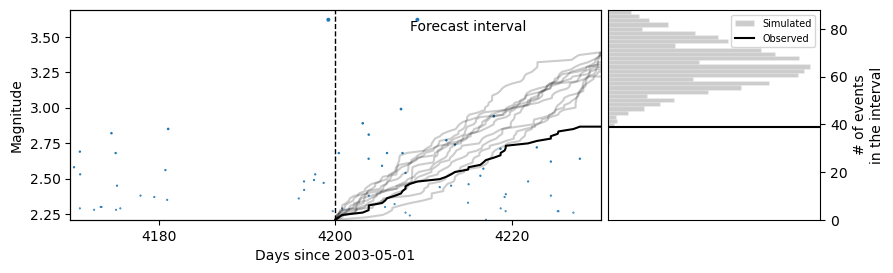

In [21]:
date_str = catalog_ds.metadata['start_ts'].strftime('%Y-%m-%d')
src.utils.visualization.visualize_trajectories(test_seq, all_forecasts,save_path=checkpoint_dir/"all_forecasts.pdf",figsize=(10,3),xlabel='Days since '+date_str)
# src.utils.visualization.visualize_trajectories(train_seq, all_forecasts,save_path=checkpoint_dir/"all_forecasts.png")

In [22]:
import  src.utils.catalog_tests as catalog_tests

N-test

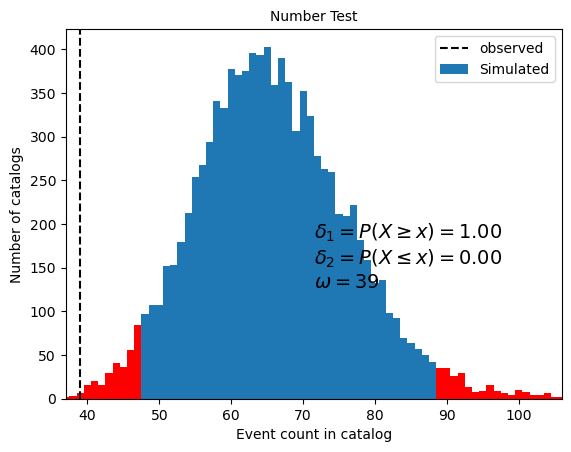

In [23]:
number_test_result = catalog_tests.run_number_test_result(
    event_counts=[len(fc) for fc in all_forecasts],
    obs_count=len(observed_seq),                   
    min_mw=catalog_ds.metadata['mag_completeness'],
    obs_name='observed',
    sim_name='Simulated',
    plot=False
)
ax= number_test_result.plot(plot_args={'figsize':(6.4,4.8),'tight_layout':False})
plt.savefig(checkpoint_dir/'n_test.pdf')

M-test

In [24]:
config_dict = {
    'min_mw': catalog_ds.metadata['mag_completeness'],
    'max_mw': 10,
    'dmw': 0.01
}

magnitude_bins, distribution = catalog_tests.compute_magnitude_distribution(
    forecast[0].mag.cpu().numpy(), 
   **config_dict
)

In [25]:
get_counts = functools.partial(catalog_tests.compute_magnitude_distribution, **config_dict)
result_dict = catalog_tests.magnitude_test_from_counts(
    observed_catalog=observed_seq,
    forecast_catalogs=all_forecasts,
    get_counts=lambda cat: get_counts(np.asarray(cat.mag.cpu())),
    verbose=False
)


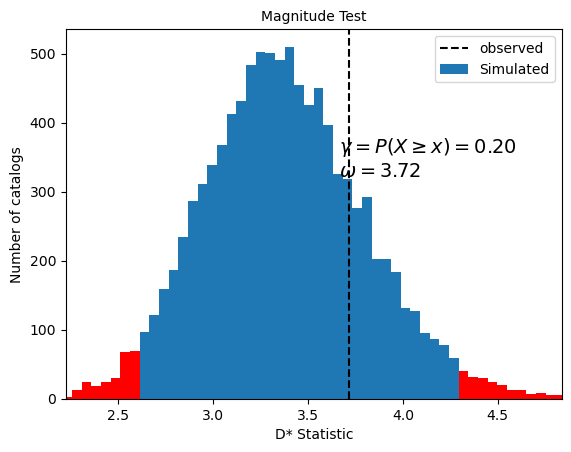

In [26]:
magnitude_test_result = catalog_tests.run_magnitude_test_result(
    result_dict=result_dict,
    obs_catalog_repr='obs',
   obs_name='observed',
    sim_name='Simulated',
    plot=False
)
magnitude_test_result.plot(plot_args={'figsize':(6.4,4.8),'tight_layout':False})
plt.savefig(checkpoint_dir/'m_test.pdf')

In [27]:
checkpoint_dir

PosixPath('../checkpoints/rtpp_20251125-223019')